In [45]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# Bibliotecas para visualização
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
PALETTE = {"Normal": "#2196F3", "Risco": "#F44336"}
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Seaborn Version:    {sns.__version__}")

TensorFlow Version: 2.20.0
Matplotlib Version: 3.10.0
Seaborn Version:    0.13.2


In [46]:

nome_arquivo = 'data/dataset2.csv'
df = pd.read_csv(nome_arquivo, sep=',')

df.columns = df.columns.str.replace('#', '').str.strip().str.lower()    
df.rename(columns={'heart_rate': 'bpm', 'activityid': 'target'}, inplace=True)

# Remove atividades transientes (ruído de transição entre atividades)
df = df[df['target'] != 'transient activities'].copy()

# Detecta quais fontes de dados estão presentes no dataset

HAS_STEPS    = 'steps' in df.columns
HAS_RR       = 'rr_interval' in df.columns
HAS_DEMO     = all(c in df.columns for c in ['age', 'sex'])
HAS_CLINICAL = any(c in df.columns for c in [
    'hist_hipertensao', 'hist_diabetes', 'hist_arritmia',
    'hist_infarto', 'hist_insuficiencia'
])

# TARGET: Redefinição para RISCO CARDÍACO
# 0 = Normal  (atividades de repouso/baixa intensidade)
# 1 = Risco   (atividades de alta intensidade)


le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
df['target'] = df['target'].apply(lambda x: 0 if x <= 2 else 1)
df.dropna(inplace=True)

print(f"Dados carregados. Shape: {df.shape}")
print(f"\nFontes de dados detectadas no banco:")
print(f"  BPM (frequência cardíaca):  sempre disponível")
print(f"  Steps (acelerômetro):       {'✓ presente' if HAS_STEPS    else '✗ ausente — coluna: steps'}")
print(f"  RR interval (ECG beat):     {'✓ presente' if HAS_RR       else '✗ ausente — coluna: rr_interval'}")
print(f"  Demográfico (age, sex):     {'✓ presente' if HAS_DEMO     else '✗ ausente — colunas: age, sex'}")
print(f"  Histórico clínico:          {'✓ presente' if HAS_CLINICAL else '✗ ausente — colunas: hist_*'}")
print(f"\nDistribuição do target: {dict(zip(*np.unique(df['target'].values, return_counts=True)))}")


Dados carregados. Shape: (1936481, 33)

Fontes de dados detectadas no banco:
  BPM (frequência cardíaca):  sempre disponível
  Steps (acelerômetro):       ✗ ausente — coluna: steps
  RR interval (ECG beat):     ✗ ausente — coluna: rr_interval
  Demográfico (age, sex):     ✗ ausente — colunas: age, sex
  Histórico clínico:          ✗ ausente — colunas: hist_*

Distribuição do target: {np.int64(0): np.int64(469923), np.int64(1): np.int64(1466558)}


In [ ]:

window_size = 5

# rolling cronológico se houver timestamp; por contagem de linhas caso contrário
HAS_TIMESTAMP = 'timestamp' in df.columns
if HAS_TIMESTAMP:
    df.index = pd.to_datetime(df['timestamp'], unit='s')
    df.sort_index(inplace=True)
    _window    = '5s'
    _window_cv = '60s'
    print("  Rolling temporal ativado: janelas de 5s (índice datetime)")
else:
    _window    = window_size
    _window_cv = 60
    print("  Aviso: sem 'timestamp' — rolling por contagem de linhas; lacunas temporais ignoradas")

# BPM (frequência cardíaca) - sempre disponível
df['bpm_rolling_mean'] = df['bpm'].rolling(window=_window).mean()
df['bpm_rolling_std']  = df['bpm'].rolling(window=_window).std()
df['bpm_diff']         = df['bpm'].diff()
temporal_features = ['bpm', 'bpm_rolling_mean', 'bpm_rolling_std', 'bpm_diff']

# PASSOS (acelerômetro) - apenas se o banco fornece 'steps'
if HAS_STEPS:
    df['steps_rolling_mean'] = df['steps'].rolling(window=_window).mean()
    STEP_THRESHOLD = 30  # passos/min
    df['is_active']  = (df['steps_rolling_mean'] >= STEP_THRESHOLD).astype(int)
    # repouso calibrado pelo percentil 10 do dataset; no cenário ideal (com subject_id):
    # df.groupby('subject_id')['bpm'].transform(lambda x: x.quantile(0.1))
    resting_bpm_proxy       = df['bpm'].quantile(0.10)
    expected_bpm_from_steps = resting_bpm_proxy + df['steps_rolling_mean'] * 0.5
    df['bpm_excess'] = df['bpm'] - expected_bpm_from_steps
    temporal_features += ['steps_rolling_mean', 'is_active', 'bpm_excess']

# RR INTERVAL (ECG beat-to-beat) - apenas se o banco fornece 'rr_interval'
if HAS_RR:
    df['rr_rolling_mean'] = df['rr_interval'].rolling(window=_window).mean()
    df['rr_rolling_std']  = df['rr_interval'].rolling(window=_window).std()
    rr_diff = df['rr_interval'].diff()
    df['rr_rmssd'] = (rr_diff ** 2).rolling(window=_window).mean().apply(np.sqrt)
    df['rr_cv']    = df['rr_rolling_std'] / (df['rr_rolling_mean'] + 1e-8)

    # irregularidade = Z-score do CV em relação à linha de base individual
    # Z > 2 significa que o CV atual está 2σ acima do próprio padrão do paciente
    cv_base_mean = df['rr_cv'].rolling(window=_window_cv, min_periods=10).mean()
    cv_base_std  = df['rr_cv'].rolling(window=_window_cv, min_periods=10).std().fillna(1e-8)
    cv_zscore    = (df['rr_cv'] - cv_base_mean) / (cv_base_std + 1e-8)
    ARRHYTHMIA_ZSCORE_THRESHOLD = 2.0
    df['irregular_rhythm'] = (cv_zscore > ARRHYTHMIA_ZSCORE_THRESHOLD).astype(int)
    temporal_features += ['rr_rolling_mean', 'rr_rolling_std', 'rr_rmssd', 'rr_cv', 'irregular_rhythm']

df.dropna(inplace=True)

# FEATURES DEMOGRÁFICAS - apenas colunas presentes no banco
demographic_features = [c for c in ['age', 'sex'] if c in df.columns]

# FEATURES CLÍNICAS - apenas colunas presentes no banco
clinical_candidates  = ['hist_hipertensao', 'hist_diabetes', 'hist_arritmia',
                        'hist_infarto', 'hist_insuficiencia']
clinical_features    = [c for c in clinical_candidates if c in df.columns]

# Features contínuas (precisam de StandardScaler)
continuous_features = [
    'bpm', 'bpm_rolling_mean', 'bpm_rolling_std', 'bpm_diff',
    'steps_rolling_mean', 'bpm_excess',
    'rr_rolling_mean', 'rr_rolling_std', 'rr_rmssd', 'rr_cv',
    'age',
]
# Features binárias (não precisam de scaling)
binary_features = [
    'is_active', 'irregular_rhythm', 'sex',
    'hist_hipertensao', 'hist_diabetes', 'hist_arritmia',
    'hist_infarto', 'hist_insuficiencia',
]

all_features = temporal_features + demographic_features + clinical_features
y = df['target'].values

print(f"Features temporais  ({len(temporal_features)}): {temporal_features}")
print(f"Features demográficas ({len(demographic_features)}): {demographic_features}")
print(f"Features clínicas   ({len(clinical_features)}): {clinical_features}")
print(f"Total de features: {len(all_features)} | Amostras: {len(df)}")


  Aviso: sem 'timestamp' — rolling por contagem de linhas; lacunas temporais ignoradas
Features temporais  (4): ['bpm', 'bpm_rolling_mean', 'bpm_rolling_std', 'bpm_diff']
Features demográficas (0): []
Features clínicas   (0): []
Total de features: 4 | Amostras: 1936477


In [48]:

from sklearn.utils.class_weight import compute_class_weight

# Calcula pesos proporcionais ao inverso da frequência de cada classe
classes = np.unique(y)
cw = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}

counts = dict(zip(*np.unique(y, return_counts=True)))
total  = len(y)
print("=" * 58)
print("  DESBALANCEAMENTO")
print("=" * 58)
for cls, cnt in sorted(counts.items()):
    label = "Normal (0)" if cls == 0 else "Risco  (1)"
    print(f"  {label}: {cnt:>9,} amostras  ({cnt / total * 100:.1f}%)")
imbalance_ratio = max(counts.values()) / min(counts.values())
print(f"\n  Proporção majoritária / minoritária: {imbalance_ratio:.1f}:1")
print(f"  Pesos calculados (sklearn balanced): {class_weight_dict}")
print("=" * 58)


  DESBALANCEAMENTO
  Normal (0):   469,923 amostras  (24.3%)
  Risco  (1): 1,466,554 amostras  (75.7%)

  Proporção majoritária / minoritária: 3.1:1
  Pesos calculados (sklearn balanced): {0: 2.060419472977488, 1: 0.6602133300239882}


In [49]:

# Separação Treino/Teste - temporal sempre presente
X_temporal = df[temporal_features].values
X_train_temp, X_test_temp, y_train, y_test = train_test_split(
    X_temporal, y, test_size=0.3, random_state=42, stratify=y
)

# Demográfico - apenas se disponível no banco
if demographic_features:
    X_demographic = df[demographic_features].values
    X_train_demo, X_test_demo, _, _ = train_test_split(
        X_demographic, y, test_size=0.3, random_state=42, stratify=y
    )

# Clínico - apenas se disponível no banco
if clinical_features:
    X_clinical = df[clinical_features].values
    X_train_clin, X_test_clin, _, _ = train_test_split(
        X_clinical, y, test_size=0.3, random_state=42, stratify=y
    )

# Scaling das features contínuas
temporal_continuous_idx = [i for i, f in enumerate(temporal_features) if f in continuous_features]

scaler_temporal = StandardScaler()
X_train_temp_scaled = X_train_temp.copy().astype(float)
X_test_temp_scaled  = X_test_temp.copy().astype(float)
if temporal_continuous_idx:
    X_train_temp_scaled[:, temporal_continuous_idx] = scaler_temporal.fit_transform(
        X_train_temp[:, temporal_continuous_idx])
    X_test_temp_scaled[:, temporal_continuous_idx]  = scaler_temporal.transform(
        X_test_temp[:, temporal_continuous_idx])

if demographic_features:
    demo_continuous_idx = [i for i, f in enumerate(demographic_features) if f in continuous_features]
    scaler_demo = StandardScaler()
    X_train_demo_scaled = X_train_demo.copy().astype(float)
    X_test_demo_scaled  = X_test_demo.copy().astype(float)
    if demo_continuous_idx:
        X_train_demo_scaled[:, demo_continuous_idx] = scaler_demo.fit_transform(
            X_train_demo[:, demo_continuous_idx].astype(float))
        X_test_demo_scaled[:, demo_continuous_idx]  = scaler_demo.transform(
            X_test_demo[:, demo_continuous_idx].astype(float))

if clinical_features:
    # Clínicas são binárias - sem scaling necessário
    X_train_clin_scaled = X_train_clin.astype(float)
    X_test_clin_scaled  = X_test_clin.astype(float)

# Função auxiliar: monta lista de inputs do modelo
def build_model_inputs(X_temp, X_demo=None, X_clin=None):
    inputs = [X_temp]
    if demographic_features and X_demo is not None:
        inputs.append(X_demo)
    if clinical_features and X_clin is not None:
        inputs.append(X_clin)
    return inputs

print("Dados separados e escalonados com sucesso.")
print(f"  Temporal:    train={X_train_temp_scaled.shape}, test={X_test_temp_scaled.shape}")
if demographic_features:
    print(f"  Demográfico: train={X_train_demo_scaled.shape}, test={X_test_demo_scaled.shape}")
if clinical_features:
    print(f"  Clínico:     train={X_train_clin_scaled.shape}, test={X_test_clin_scaled.shape}")


Dados separados e escalonados com sucesso.
  Temporal:    train=(1355533, 4), test=(580944, 4)


In [50]:

# Reamostragem  -  apenas no conjunto de treino
# Opções: 'smote' | 'adasyn' | 'undersample' | 'smotetomek' | None
RESAMPLE_STRATEGY = 'None'

# Aceita tanto None quanto a string 'None' para desativar
if RESAMPLE_STRATEGY == 'None':
    RESAMPLE_STRATEGY = None

if RESAMPLE_STRATEGY is not None:
    try:
        from imblearn.over_sampling import SMOTE, ADASYN
        from imblearn.under_sampling import RandomUnderSampler
        from imblearn.combine import SMOTETomek
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
        from imblearn.over_sampling import SMOTE, ADASYN
        from imblearn.under_sampling import RandomUnderSampler
        from imblearn.combine import SMOTETomek

    # Concatena todos os branches de treino para reamostrar conjuntamente
    flat_rs = [X_train_temp_scaled]
    if demographic_features:
        flat_rs.append(X_train_demo_scaled)
    if clinical_features:
        flat_rs.append(X_train_clin_scaled)
    X_rs = np.hstack(flat_rs)

    strategy_map = {
        'smote':       SMOTE(random_state=42, k_neighbors=5),
        'adasyn':      ADASYN(random_state=42),
        'undersample': RandomUnderSampler(random_state=42, sampling_strategy=0.5),
        'smotetomek':  SMOTETomek(random_state=42),
    }
    X_rs_resampled, y_train = strategy_map[RESAMPLE_STRATEGY].fit_resample(X_rs, y_train)

    # SMOTE/ADASYN anexam os sintéticos ao final - embaralha para que validation_split
    # não pegue só a classe sintética e produza val_accuracy/recall/pr_auc = 0
    shuffle_idx    = np.random.default_rng(42).permutation(len(y_train))
    X_rs_resampled = X_rs_resampled[shuffle_idx]
    y_train        = y_train[shuffle_idx]

    # Re-divide o array plano de volta nos branches originais
    n_temp = len(temporal_features)
    X_train_temp_scaled = X_rs_resampled[:, :n_temp]
    offset = n_temp
    if demographic_features:
        n_demo = len(demographic_features)
        X_train_demo_scaled = X_rs_resampled[:, offset:offset + n_demo]
        offset += n_demo
    if clinical_features:
        X_train_clin_scaled = X_rs_resampled[:, offset:]

    after = dict(zip(*np.unique(y_train, return_counts=True)))
    print(f"  '{RESAMPLE_STRATEGY}' aplicada ao treino.")
    print(f"  Distribuição pós-reamostragem: {after}")
    print(f"  Total de amostras de treino:   {len(y_train):,}")
else:
    before = dict(zip(*np.unique(y_train, return_counts=True)))
    print(f"  Reamostragem desativada. Distribuição de treino: {before}")


  Reamostragem desativada. Distribuição de treino: {np.int64(0): np.int64(328946), np.int64(1): np.int64(1026587)}


In [51]:

# USE_FOCAL_LOSS=True foca o gradiente nas amostras difíceis da classe minoritária
USE_FOCAL_LOSS = True

class BinaryFocalLoss(keras.losses.Loss):
    """gamma reduz o peso de exemplos fáceis; alpha pondera a classe minoritária."""
    def __init__(self, gamma=2.0, alpha=0.75, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        return alpha_t * tf.pow(1 - p_t, self.gamma) * bce

# Modelo Multi-Input - arquitetura adaptativa conforme features disponíveis

all_inputs   = []
all_branches = []

# Branch Temporal - sempre presente
input_temporal = keras.Input(shape=(len(temporal_features),), name='input_temporal')
x_temp = layers.Dense(64, activation='relu', name='temporal_dense1')(input_temporal)
x_temp = layers.Dropout(0.3, name='temporal_dropout')(x_temp)
x_temp = layers.Dense(32, activation='relu', name='temporal_dense2')(x_temp)
all_inputs.append(input_temporal)
all_branches.append(x_temp)

# Branch Demográfico - apenas se age/sex estiverem no banco
if demographic_features:
    input_demographic = keras.Input(shape=(len(demographic_features),), name='input_demographic')
    x_demo = layers.Dense(16, activation='relu', name='demo_dense')(input_demographic)
    all_inputs.append(input_demographic)
    all_branches.append(x_demo)

# Branch Clínico - apenas se hist_* estiverem no banco
if clinical_features:
    input_clinical = keras.Input(shape=(len(clinical_features),), name='input_clinical')
    x_clin = layers.Dense(16, activation='relu', name='clinical_dense')(input_clinical)
    all_inputs.append(input_clinical)
    all_branches.append(x_clin)

# Fusão dos branches disponíveis
merged = layers.Concatenate(name='merge')(all_branches) if len(all_branches) > 1 else all_branches[0]
x = layers.Dense(64, activation='relu', name='shared_dense1')(merged)
x = layers.Dropout(0.2, name='shared_dropout')(x)
x = layers.Dense(32, activation='relu', name='shared_dense2')(x)
output = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs=all_inputs, outputs=output, name='cardiac_risk_model')

# SMOTE já balanceia -> alpha=0.5 (efeito de foco γ sem viés de classe)
# Sem SMOTE -> alpha=0.75 compensa a classe minoritária via Focal Loss
_focal_alpha = 0.5 if RESAMPLE_STRATEGY is not None else 0.75

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=BinaryFocalLoss(gamma=2.0, alpha=_focal_alpha) if USE_FOCAL_LOSS else 'binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(curve='PR', name='pr_auc')]
)

loss_label = (f"Focal Loss (gamma=2.0, alpha={_focal_alpha})" if USE_FOCAL_LOSS
              else "Binary Cross-Entropy")
print(f"Modelo construído com {len(all_inputs)} branch(es): "
      f"temporal{'+ demográfico' if demographic_features else ''}{'+ clínico' if clinical_features else ''}")
print(f"  Loss: {loss_label}")
model.summary()


Modelo construído com 1 branch(es): temporal
  Loss: Focal Loss (gamma=2.0, alpha=0.75)


Model: "cardiac_risk_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_temporal (InputLayer)     │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_dense1 (Dense)         │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_dropout (Dropout)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_dense2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense1 (Dense)           │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dropout (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,625 (25.88 KB)

 Trainable params: 6,625 (25.88 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:

# Depois do SMOTE y_train já está balanceado - class_weight só é necessário sem reamostragem
_class_weight = None if RESAMPLE_STRATEGY is not None else class_weight_dict

train_inputs = build_model_inputs(
    X_train_temp_scaled,
    X_train_demo_scaled if demographic_features else None,
    X_train_clin_scaled if clinical_features    else None,
)

# val_loss é mais estável que val_pr_auc com loss customizada
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, mode='min',
    restore_best_weights=True, verbose=1
)

print("  Compensação de desbalanceamento ativa:")
print(f"    Reamostragem:  {RESAMPLE_STRATEGY or 'nenhuma'}")
print(f"    class_weight:  {'desativado (SMOTE já balanceou)' if _class_weight is None else str(_class_weight)}")
print(f"    Focal alpha:   {_focal_alpha if USE_FOCAL_LOSS else 'N/A'}")
print()

history = model.fit(
    train_inputs,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=_class_weight,
    callbacks=[early_stop],
    verbose=1
)


  Compensação de desbalanceamento ativa:
    Reamostragem:  nenhuma
    class_weight:  {0: 2.060419472977488, 1: 0.6602133300239882}
    Focal alpha:   0.75

Epoch 1/50
33889/33889 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.7574 - loss: 0.0719 - pr_auc: 0.8645 - recall: 0.9999 - val_accuracy: 0.7570 - val_loss: 0.0670 - val_pr_auc: 0.9268 - val_recall: 1.0000
Epoch 2/50
33889/33889 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - accuracy: 0.7574 - loss: 0.0719 - pr_auc: 0.8799 - recall: 1.0000 - val_accuracy: 0.7570 - val_loss: 0.0665 - val_pr_auc: 0.9240 - val_recall: 1.0000
Epoch 3/50
33889/33889 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.7574 - loss: 0.0719 - pr_auc: 0.8961 - recall: 1.0000 - val_accuracy: 0.7570 - val_loss: 0.0654 - val_pr_auc: 0.9317 - val_recall: 1.0000
Epoch 4/50
33889/33889 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.7574 - loss: 0.0719 - pr_auc: 0.9032 - recall: 1.0000 - val_accuracy: 0.7570 - val_loss: 0.0681 - val_pr_auc: 0.9176 - val_recall: 1.0000
Epoch 

In [ ]:

from sklearn.metrics import precision_recall_curve, average_precision_score

test_inputs = build_model_inputs(
    X_test_temp_scaled,
    X_test_demo_scaled if demographic_features else None,
    X_test_clin_scaled if clinical_features    else None,
)

probs_anomalia = model.predict(test_inputs).flatten()
probs_normal   = 1.0 - probs_anomalia

# otimiza threshold via F2 (beta=2) para a classe Risco (pos_label=1)
# Prioridade é maximizar recall de anomalias — perder um risco real é o erro crítico
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(
    y_test, probs_anomalia, pos_label=1
)
pr_auc_risco = average_precision_score(y_test, probs_anomalia, pos_label=1)
f2_scores = ((1 + 4) * precisions_pr * recalls_pr
             / (4 * precisions_pr + recalls_pr + 1e-8))
best_idx  = int(np.argmax(f2_scores[:-1]))   # último ponto não possui threshold associado
THRESHOLD = float(thresholds_pr[best_idx])

print(f"  Threshold otimizado (F2-Risco):  {THRESHOLD:.4f}")
print(f"  PR-AUC (classe Risco):           {pr_auc_risco:.4f}")

preds_custom = np.where(probs_anomalia >= THRESHOLD, 1, 0)

print("\n--- Resultados: Modelo de Risco Cardíaco ---")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, preds_custom))
print(f"\nRelatório de Classificação (Threshold = {THRESHOLD:.4f}):")
print(classification_report(y_test, preds_custom, target_names=['Normal (0)', 'Anômalo/Risco (1)']))


18155/18155 ━━━━━━━━━━━━━━━━━━━━ 16s 898us/step
  Threshold otimizado (F2-Risco):  0.6037
  PR-AUC (classe Risco):           0.9395

--- Resultados: Modelo de Risco Cardíaco ---

Matriz de Confusão:
[[     0 140977]
 [     0 439967]]

Relatório de Classificação (Threshold = 0.6037):
                   precision    recall  f1-score   support

       Normal (0)       0.00      0.00      0.00    140977
Anômalo/Risco (1)       0.76      1.00      0.86    439967

         accuracy                           0.76    580944
        macro avg       0.38      0.50      0.43    580944
     weighted avg       0.57      0.76      0.65    580944



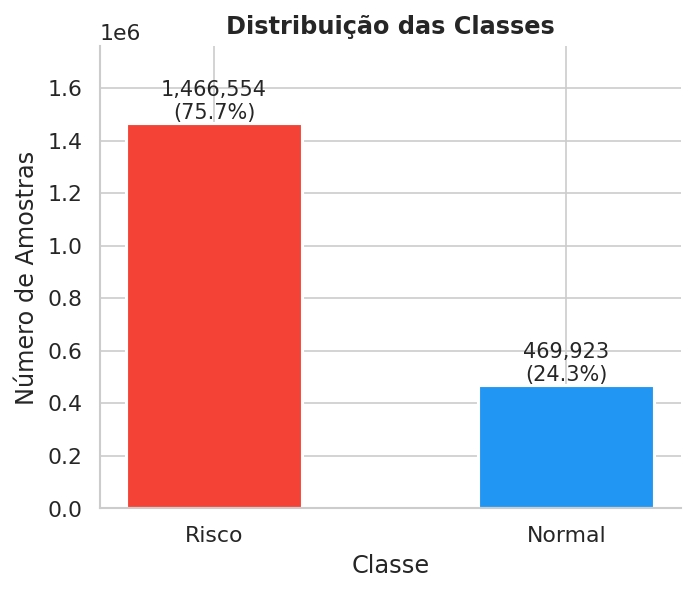

  Salvo: figures/01_class_distribution.png


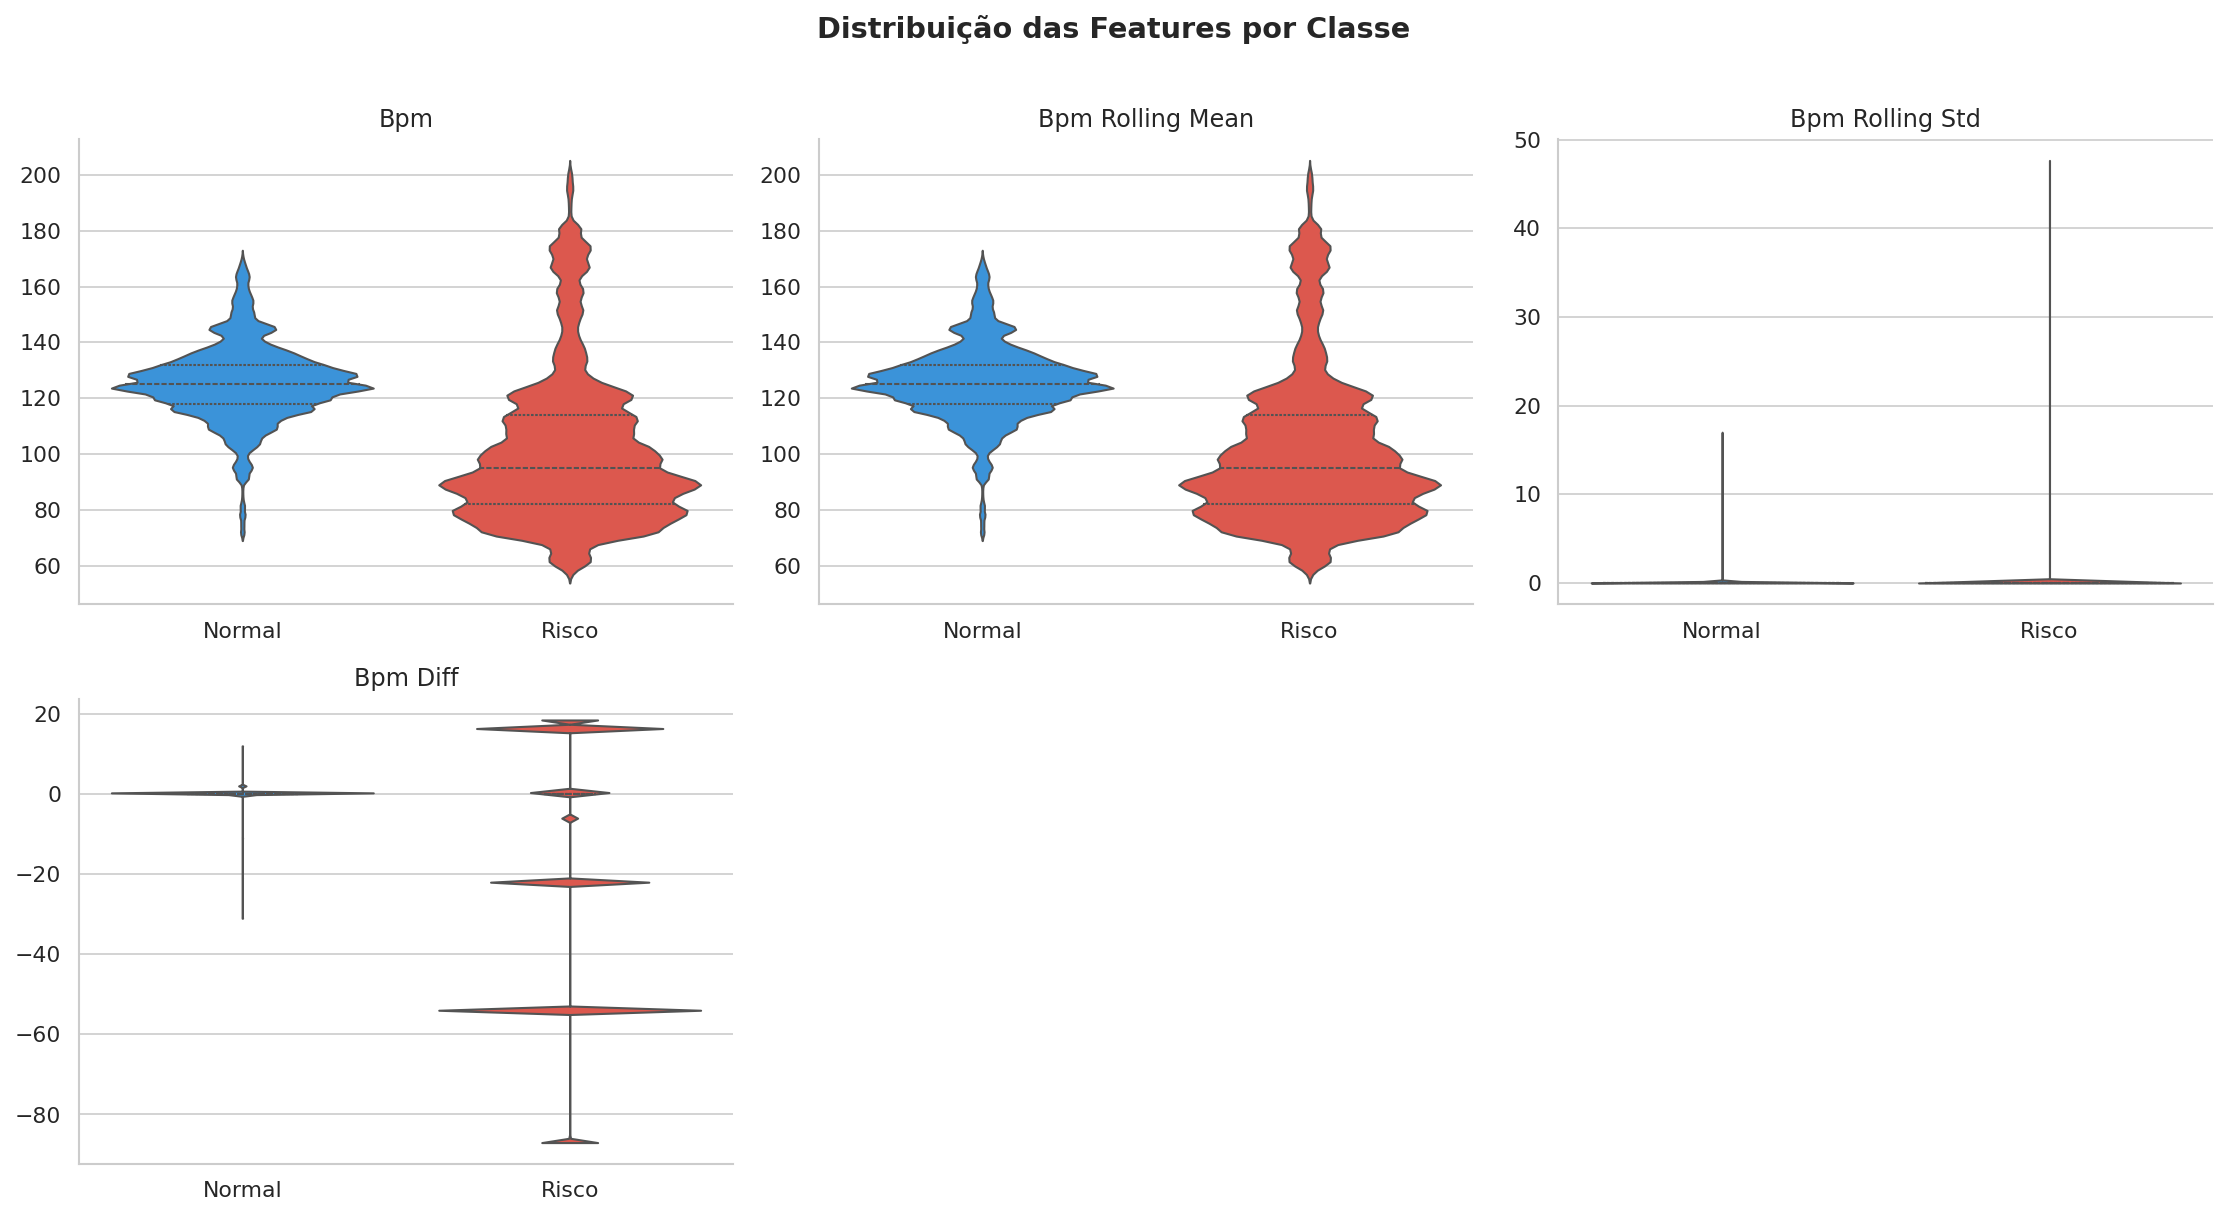

  Salvo: figures/02_feature_distributions.png


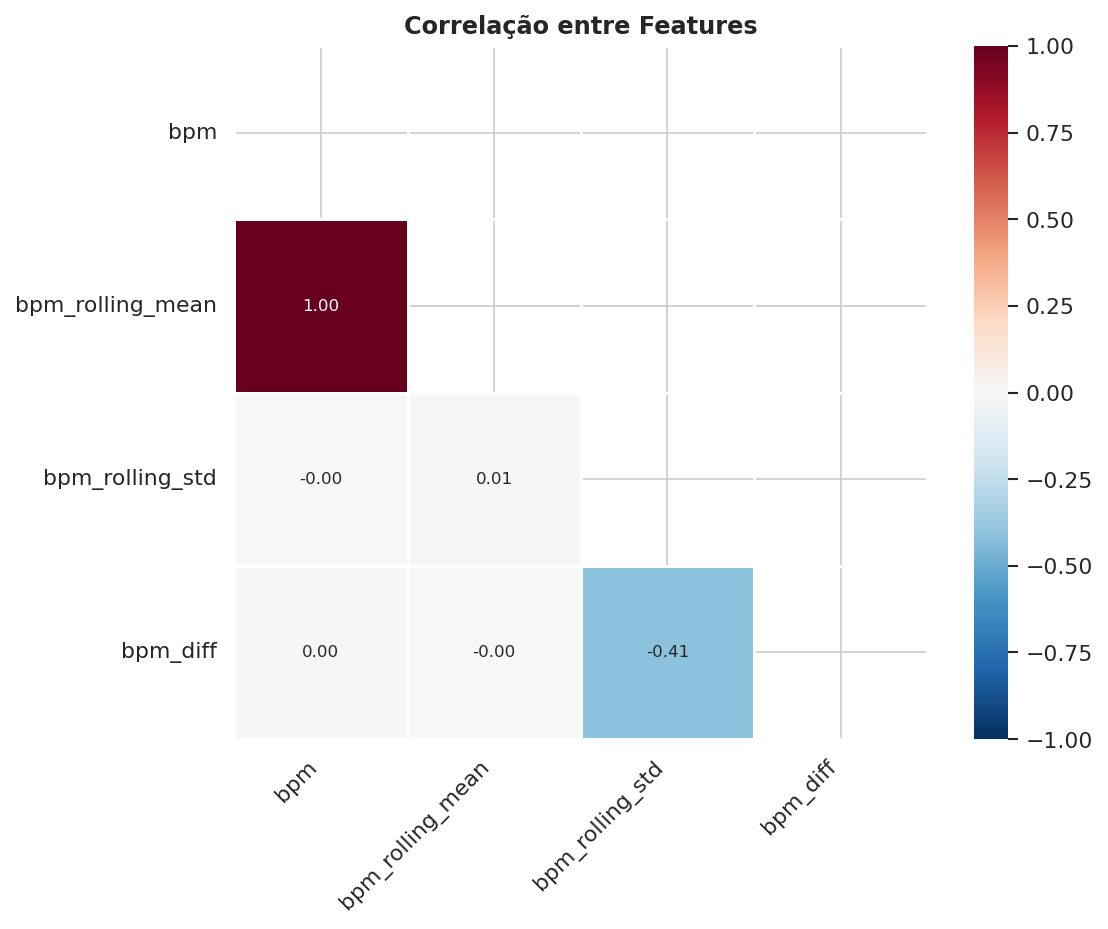

  Salvo: figures/03_feature_correlation.png


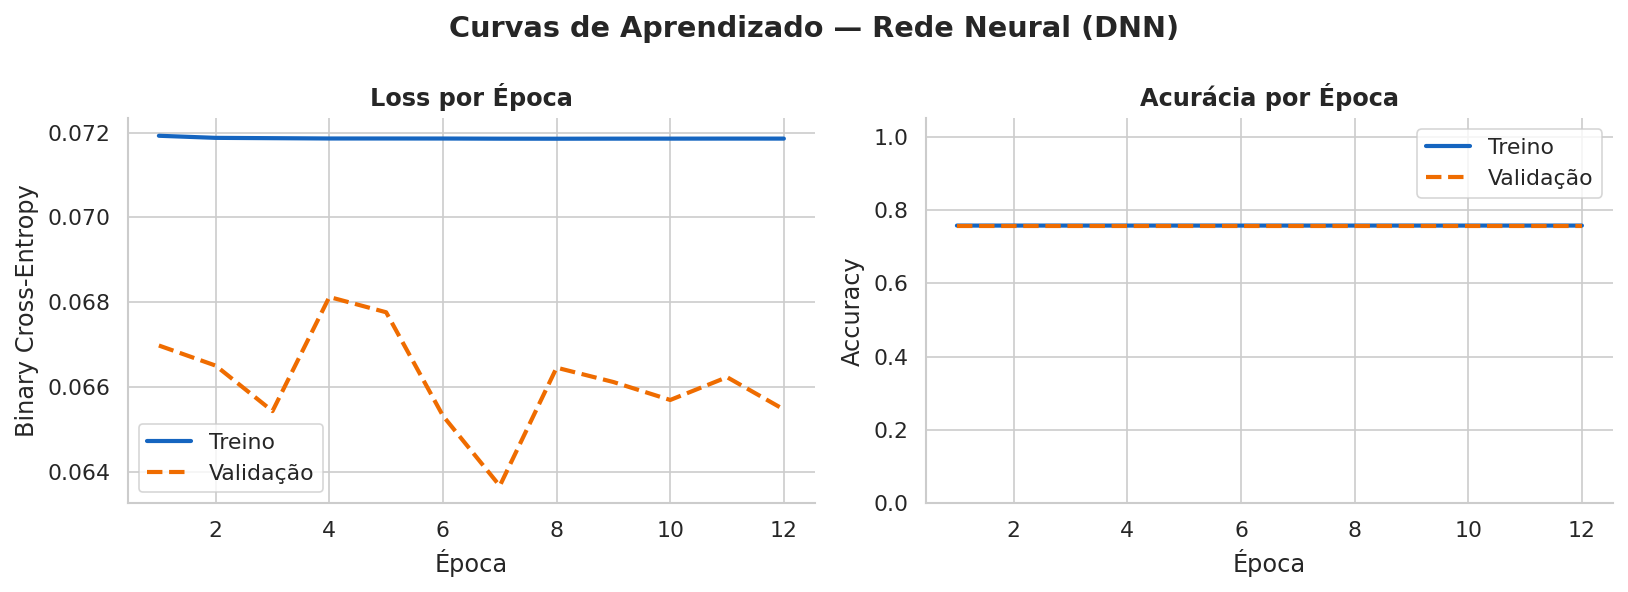

  Salvo: figures/04_training_curves.png


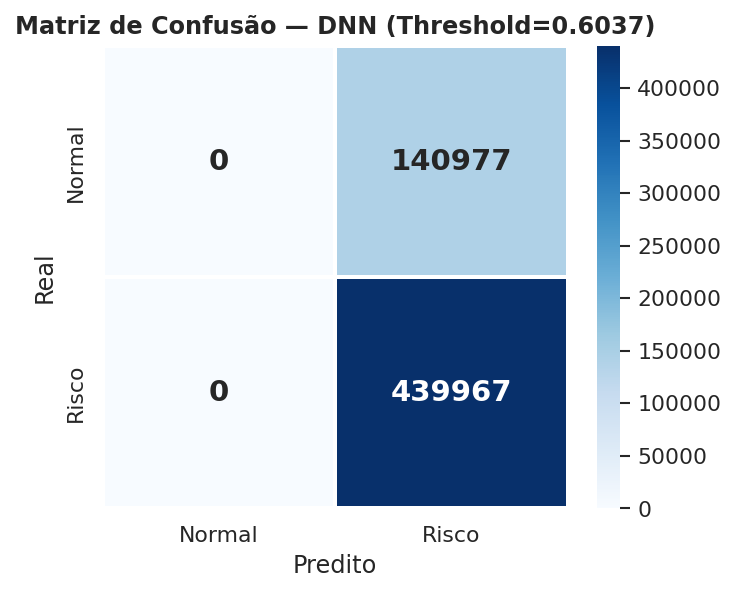

  Salvo: figures/05_confusion_dnn.png


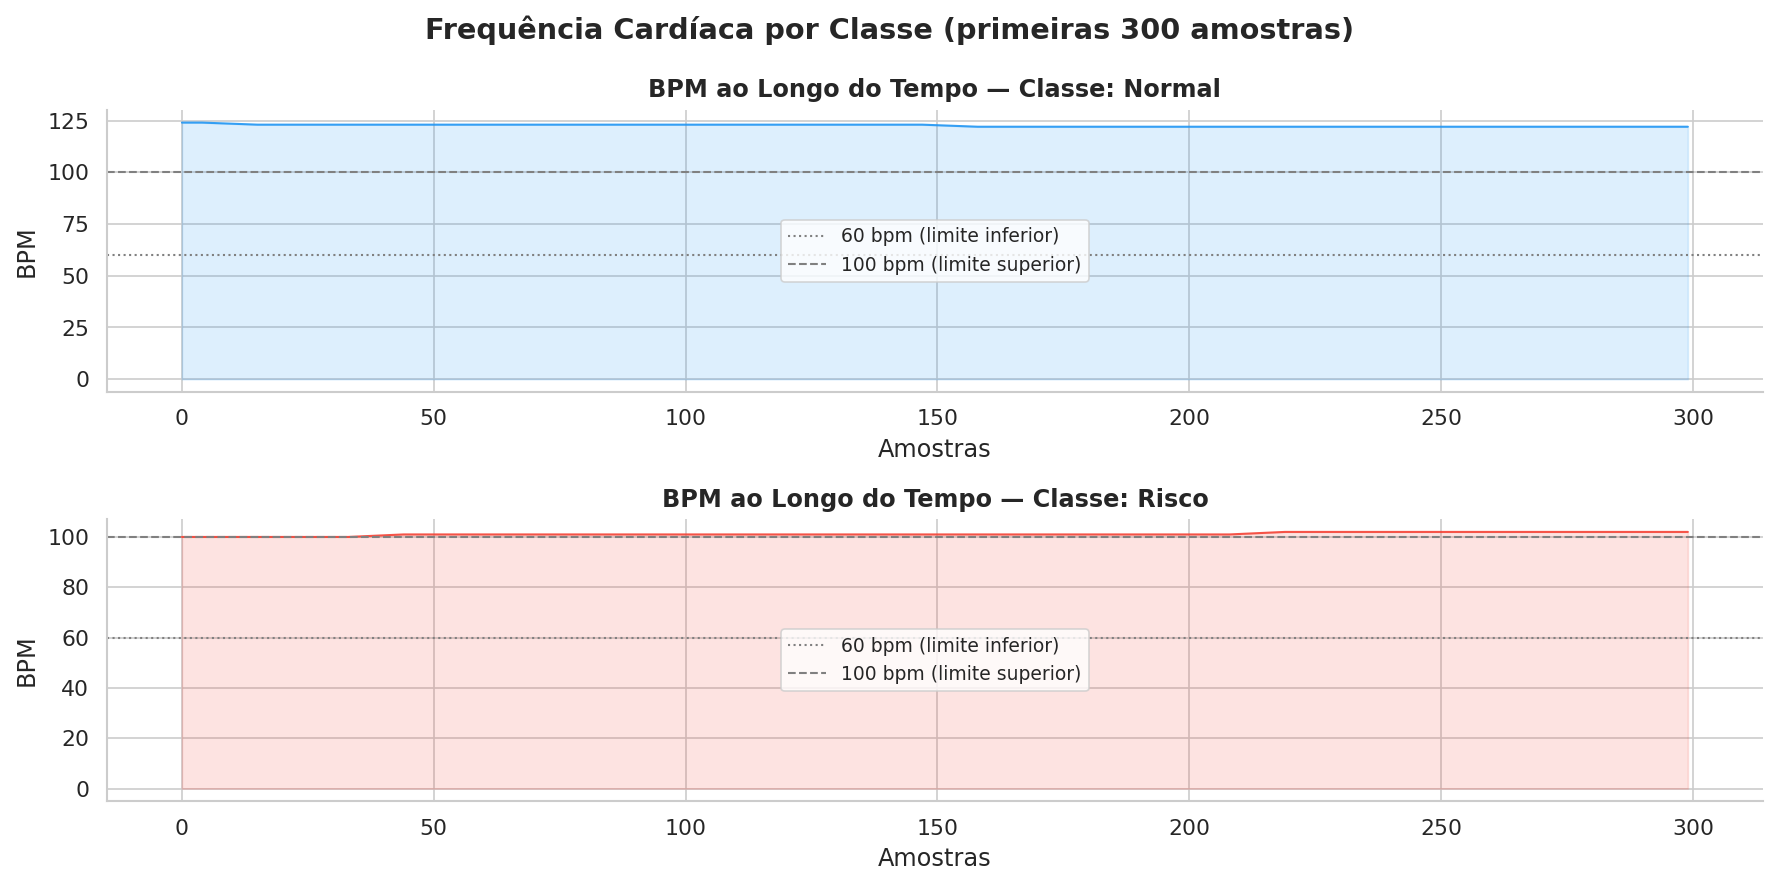

  Salvo: figures/06_bpm_over_time.png


KeyboardInterrupt: 

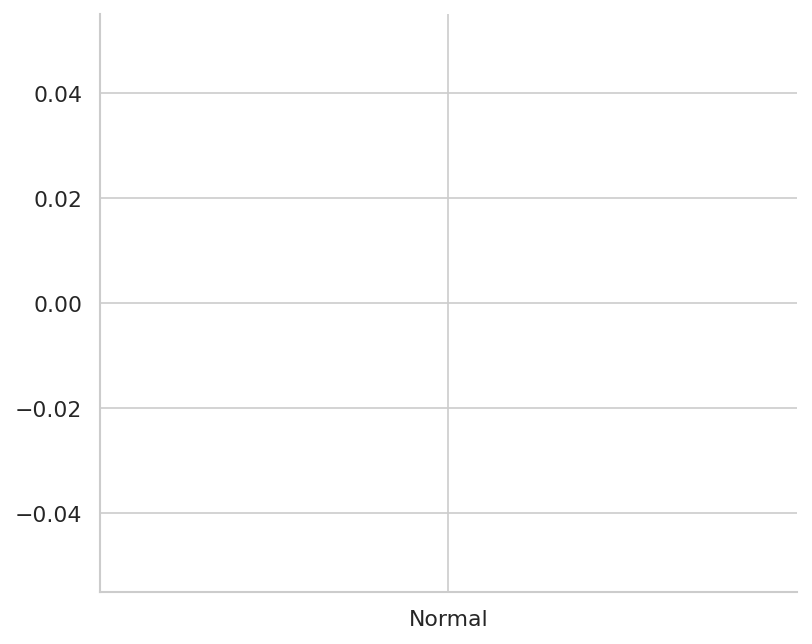

In [54]:

# Gera os graficos

label_map  = {0: "Normal", 1: "Risco"}
target_col = pd.Series(y, name="target").map(label_map)

def save_fig(name):
    path = f"{OUTPUT_DIR}/{name}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"  Salvo: {path}")


# Distribuição das classes

fig, ax = plt.subplots(figsize=(5, 4))
counts = target_col.value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[l] for l in counts.index],
              width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,}\n({val/len(target_col)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuição das Classes", fontweight="bold")
ax.set_ylabel("Número de Amostras")
ax.set_xlabel("Classe")
ax.set_ylim(0, counts.max() * 1.2)
save_fig("01_class_distribution")


# Distribuição das features temporais
df_plot = df[temporal_features + ['target']].copy()
df_plot['Classe'] = df_plot['target'].map(label_map)

plot_feats = [f for f in temporal_features if f in continuous_features]
n_feats = len(plot_feats)
ncols = 3
nrows = int(np.ceil(n_feats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, feat in enumerate(plot_feats):
    sns.violinplot(
        data=df_plot, x="Classe", y=feat,
        palette=PALETTE, inner="quartile",
        order=["Normal", "Risco"], ax=axes[i]
    )
    axes[i].set_title(feat.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribuição das Features por Classe", fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("02_feature_distributions")


# Correlação entre features

corr_feats = [f for f in all_features if f in df.columns]
corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(max(8, len(corr_feats)), max(6, len(corr_feats) - 2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax, square=True,
    vmin=-1, vmax=1
)
ax.set_title("Correlação entre Features", fontweight="bold")
plt.xticks(rotation=45, ha="right")
save_fig("03_feature_correlation")


# Curvas de treino

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'],    color="#1565C0", label="Treino",    linewidth=2)
ax1.plot(epochs_range, history.history['val_loss'], color="#EF6C00", label="Validação", linewidth=2, linestyle="--")
ax1.set_title("Loss por Época", fontweight="bold")
ax1.set_xlabel("Época")
ax1.set_ylabel("Binary Cross-Entropy")
ax1.legend()

ax2.plot(epochs_range, history.history['accuracy'],    color="#1565C0", label="Treino",    linewidth=2)
ax2.plot(epochs_range, history.history['val_accuracy'], color="#EF6C00", label="Validação", linewidth=2, linestyle="--")
ax2.set_title("Acurácia por Época", fontweight="bold")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.suptitle("Curvas de Aprendizado — Rede Neural (DNN)", fontweight="bold")
plt.tight_layout()
save_fig("04_training_curves")


# Matriz de confusão

def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Risco"],
        yticklabels=["Normal", "Risco"],
        linewidths=1, linecolor="white", ax=ax,
        annot_kws={"size": 14, "weight": "bold"}
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    save_fig(filename)

plot_confusion(y_test, preds_custom,
               f"Matriz de Confusão — DNN (Threshold={THRESHOLD:.4f})",
               "05_confusion_dnn")


# BPM ao longo do tempo

N_SAMPLE = 300
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

for ax, (label, color) in zip(axes, [("Normal", "#2196F3"), ("Risco", "#F44336")]):
    subset = df[df['target'] == (0 if label == "Normal" else 1)]['bpm'].head(N_SAMPLE)
    ax.plot(subset.values, color=color, linewidth=1, alpha=0.9)
    ax.fill_between(range(len(subset)), subset.values, alpha=0.15, color=color)
    ax.axhline(60,  color="gray", linestyle=":", linewidth=1, label="60 bpm (limite inferior)")
    ax.axhline(100, color="gray", linestyle="--", linewidth=1, label="100 bpm (limite superior)")
    ax.set_title(f"BPM ao Longo do Tempo — Classe: {label}", fontweight="bold")
    ax.set_ylabel("BPM")
    ax.set_xlabel("Amostras")
    ax.legend(fontsize=9)

plt.suptitle("Frequência Cardíaca por Classe (primeiras 300 amostras)", fontweight="bold")
plt.tight_layout()
save_fig("06_bpm_over_time")


# BPM - Boxplot por Classe

fig, ax = plt.subplots(figsize=(6, 5))
df_box = df[['bpm', 'target']].copy()
df_box['Classe'] = df_box['target'].map(label_map)
sns.boxplot(data=df_box, x="Classe", y="bpm",
            palette=PALETTE, order=["Normal", "Risco"],
            width=0.5, linewidth=1.5,
            flierprops=dict(marker="o", markersize=2, alpha=0.3),
            ax=ax)
ax.axhline(60,  color="gray", linestyle=":", linewidth=1.2)
ax.axhline(100, color="gray", linestyle="--", linewidth=1.2)
ax.set_title("Frequência Cardíaca (BPM) por Classe", fontweight="bold")
ax.set_ylabel("BPM")
ax.set_xlabel("Classe")
save_fig("09_bpm_boxplot")


# RR Interval, se disponível

if HAS_RR:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    df_rr = df[['rr_interval', 'rr_rmssd', 'target']].copy()
    df_rr['Classe'] = df_rr['target'].map(label_map)

    sns.violinplot(data=df_rr, x="Classe", y="rr_interval",
                   palette=PALETTE, inner="quartile",
                   order=["Normal", "Risco"], ax=axes[0])
    axes[0].set_title("RR Interval por Classe", fontweight="bold")
    axes[0].set_ylabel("RR Interval (ms)")

    sns.violinplot(data=df_rr, x="Classe", y="rr_rmssd",
                   palette=PALETTE, inner="quartile",
                   order=["Normal", "Risco"], ax=axes[1])
    axes[1].set_title("RMSSD (HRV) por Classe", fontweight="bold")
    axes[1].set_ylabel("RMSSD (ms)")

    plt.suptitle("Variabilidade da Frequência Cardíaca (HRV)", fontweight="bold")
    plt.tight_layout()
    save_fig("10_hrv_rr_analysis")

print("\n" + "="*60)
print(f"  Gráficos 01–06, 09-10 salvos em: ./{OUTPUT_DIR}/")
print("  Gráficos 07 e 08 gerados após os baselines (próxima célula).")
print("="*60)


In [ ]:

print("\n" + "="*60)
print("   AVALIAÇÃO DOS BASELINES DE COMPARAÇÃO")
print("="*60)

# Raw test slice para Baseline 3 (Regras Clínicas) e Híbrido
_, df_test_raw, _, _ = train_test_split(df, y, test_size=0.3, random_state=42, stratify=y)

# Features concatenadas para modelos clássicos (sklearn)
flat_parts_train = [X_train_temp_scaled]
flat_parts_test  = [X_test_temp_scaled]
if demographic_features:
    flat_parts_train.append(X_train_demo_scaled)
    flat_parts_test.append(X_test_demo_scaled)
if clinical_features:
    flat_parts_train.append(X_train_clin_scaled)
    flat_parts_test.append(X_test_clin_scaled)

X_train_flat = np.hstack(flat_parts_train)
X_test_flat  = np.hstack(flat_parts_test)

def print_baseline_results(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred,
                                target_names=['Normal (0)', 'Anômalo/Risco (1)'],
                                zero_division=0))


# Baseline 1: Regressão Logística
log_reg = LogisticRegression(class_weight={0: 3.0, 1: 1.0}, random_state=42, max_iter=1000)
log_reg.fit(X_train_flat, y_train)
log_preds = log_reg.predict(X_test_flat)
print_baseline_results("Baseline 1: Regressão Logística (todas as features)", y_test, log_preds)


# Baseline 2: Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight={0: 3.0, 1: 1.0},
    random_state=42, n_jobs=-1,
)
rf_clf.fit(X_train_flat, y_train)
rf_probs = rf_clf.predict_proba(X_test_flat)[:, 1]
rf_preds = np.where((1 - rf_probs) >= THRESHOLD, 0, 1)
print_baseline_results(f"Baseline 2: Random Forest (threshold = {THRESHOLD:.4f})", y_test, rf_preds)



   AVALIAÇÃO DOS BASELINES DE COMPARAÇÃO

--- Baseline 1: Regressão Logística (todas as features) ---
Matriz de Confusão:
[[118366  22611]
 [107457 332510]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.52      0.84      0.65    140977
Anômalo/Risco (1)       0.94      0.76      0.84    439967

         accuracy                           0.78    580944
        macro avg       0.73      0.80      0.74    580944
     weighted avg       0.84      0.78      0.79    580944


--- Baseline 2: Random Forest (threshold = 0.3940) ---
Matriz de Confusão:
[[130989   9988]
 [120751 319216]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.52      0.93      0.67    140977
Anômalo/Risco (1)       0.97      0.73      0.83    439967

         accuracy                           0.77    580944
        macro avg       0.74      0.83      0.75    580944
     weighted avg  


--- Baseline 3: Regras Clínicas (HRR + sustentação) ---
Matriz de Confusão:
[[140977      0]
 [439959      8]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.24      1.00      0.39    140977
Anômalo/Risco (1)       1.00      0.00      0.00    439967

         accuracy                           0.24    580944
        macro avg       0.62      0.50      0.20    580944
     weighted avg       0.82      0.24      0.09    580944



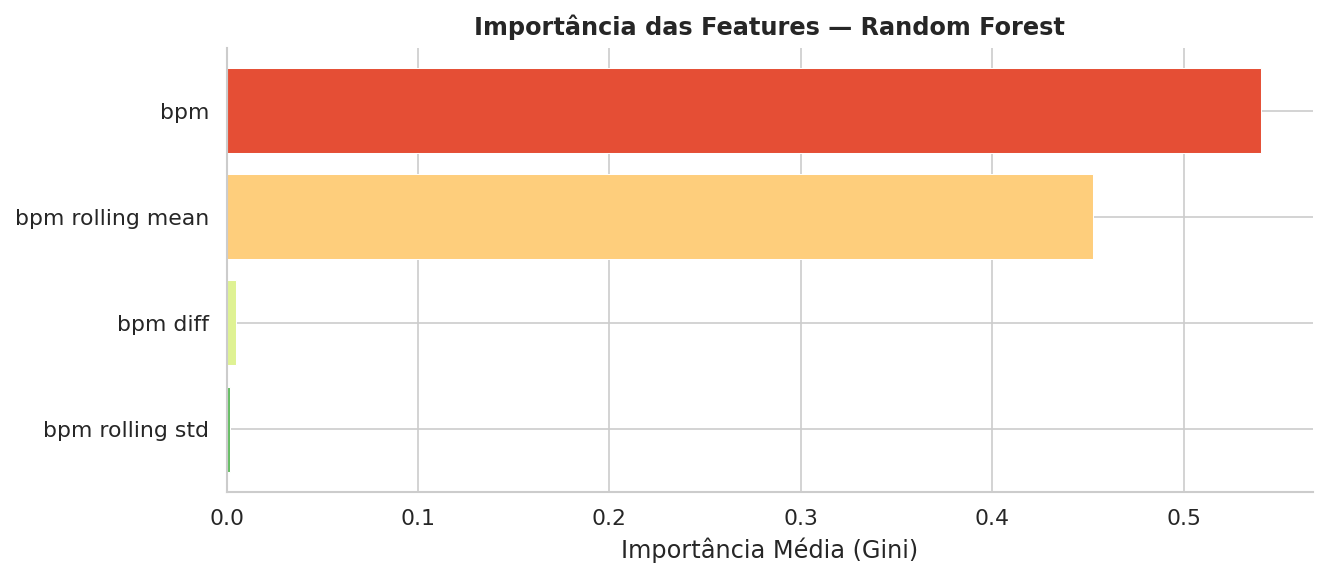

  Salvo: figures/07_feature_importance_rf.png


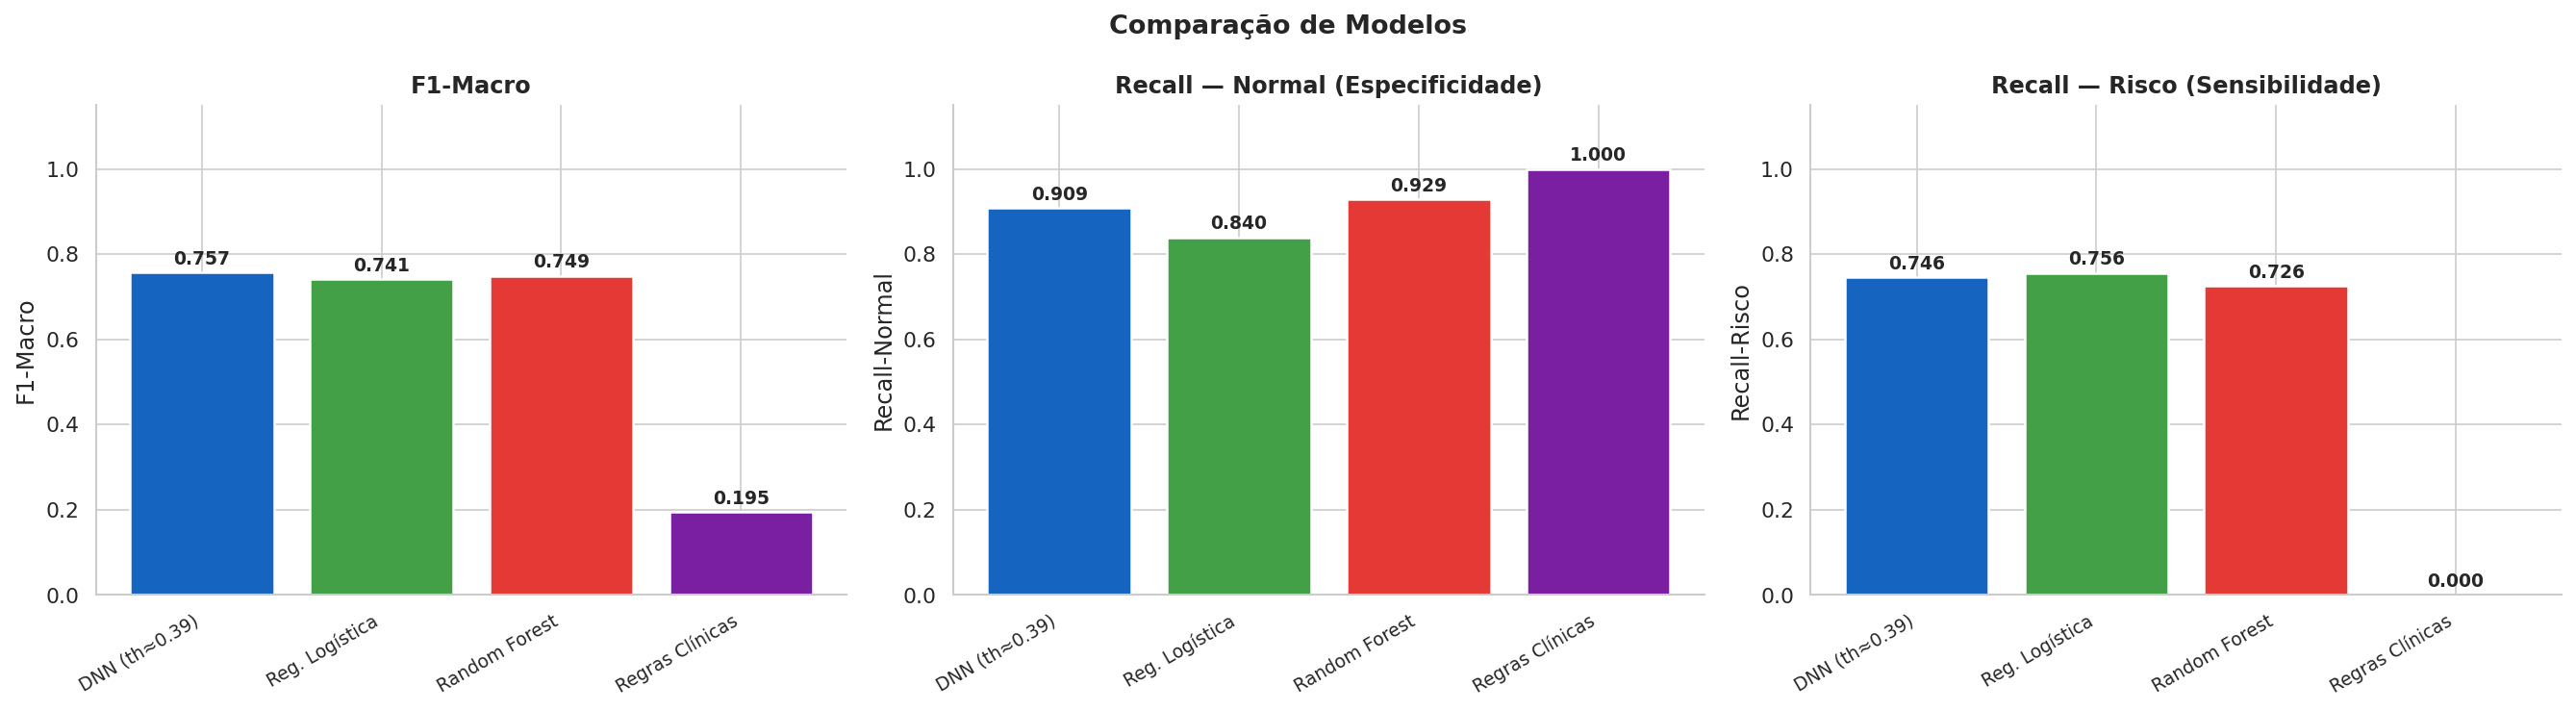

  Salvo: figures/08_model_comparison.png
         Modelo  F1-Macro  Recall-Normal  Recall-Risco  Acurácia
  DNN (th≈0.39)     0.757          0.909         0.746     0.785
 Reg. Logística     0.741          0.840         0.756     0.776
  Random Forest     0.749          0.929         0.726     0.775
Regras Clínicas     0.195          1.000         0.000     0.243


In [ ]:
# Baseline 3: Regras Clínicas (melhorada)

SUSTAIN_K = 3  # janelas consecutivas com anomalia necessárias para disparar alerta

def rule_based_predict(df_test, sustain_k=SUSTAIN_K):
    df_r = df_test.reset_index(drop=True)

    bpm_rest_est = df_r['bpm'].quantile(0.10)          # proxy de FC de repouso (percentil 10)
    hr_max       = (220 - df_r['age'].mean()) if HAS_DEMO else 190
    hrr_pct      = ((df_r['bpm'] - bpm_rest_est) / (hr_max - bpm_rest_est + 1e-8)).clip(0, 1)

    anomalia = (hrr_pct > 0.85) | (df_r['bpm'] <= 40)   # >85% HRR ou bradicardia

    if HAS_STEPS and 'is_active' in df_r.columns:
        # Taquicardia em repouso: HRR elevado sem atividade física detectada
        anomalia = anomalia | ((hrr_pct > 0.80) & (df_r['is_active'] == 0))
        if 'bpm_excess' in df_r.columns:
            anomalia = anomalia | (df_r['bpm_excess'] > 30)

    if HAS_RR and 'irregular_rhythm' in df_r.columns:
        anomalia = anomalia | (df_r['irregular_rhythm'] == 1)

    if HAS_CLINICAL:
        hist_cols = [c for c in ['hist_arritmia', 'hist_infarto', 'hist_insuficiencia']
                     if c in df_r.columns]
        if hist_cols and 'bpm_excess' in df_r.columns:
            alto_risco = (df_r[hist_cols].max(axis=1) == 1) & (df_r['bpm_excess'] > 15)
            anomalia   = anomalia | alto_risco

    anomalia_sustained = (
        anomalia.rolling(sustain_k, min_periods=sustain_k)
                .sum()
                .fillna(0) >= sustain_k
    )
    return anomalia_sustained.astype(int).values


rule_preds = rule_based_predict(df_test_raw)
print_baseline_results("Baseline 3: Regras Clínicas (HRR + sustentação)", y_test, rule_preds)


# Importância das features (RF baseline já treinado) (figura)

feature_names_flat = (temporal_features
                      + (demographic_features if demographic_features else [])
                      + (clinical_features    if clinical_features    else []))

importances = rf_clf.feature_importances_
indices     = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, max(4, len(feature_names_flat) * 0.35)))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(feature_names_flat)))
ax.barh(
    [feature_names_flat[i].replace("_", " ") for i in indices[::-1]],
    importances[indices[::-1]],
    color=colors_bar, edgecolor="white", linewidth=0.5
)
ax.set_title("Importância das Features — Random Forest", fontweight="bold")
ax.set_xlabel("Importância Média (Gini)")
plt.tight_layout()
save_fig("07_feature_importance_rf")


# Comparação de todos os modelos (figura)

def model_metrics(y_true, y_pred, name):
    return {
        "Modelo":        name,
        "F1-Macro":      round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "Recall-Normal": round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 3),
        "Recall-Risco":  round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        "Acurácia":      round((y_pred == y_true).mean(), 3),
    }

log_preds_viz = log_reg.predict(X_test_flat)
rf_probs_viz  = rf_clf.predict_proba(X_test_flat)[:, 1]
rf_preds_viz  = np.where((1 - rf_probs_viz) >= THRESHOLD, 0, 1)

metrics_list = [
    model_metrics(y_test, preds_custom,  f"DNN (th≈{THRESHOLD:.2f})"),
    model_metrics(y_test, log_preds_viz, "Reg. Logística"),
    model_metrics(y_test, rf_preds_viz,  "Random Forest"),
    model_metrics(y_test, rule_preds,    "Regras Clínicas"),
]

df_metrics = pd.DataFrame(metrics_list)
bar_colors  = ["#1565C0", "#43A047", "#E53935", "#7B1FA2"]

metric_cols   = ["F1-Macro", "Recall-Normal", "Recall-Risco"]
metric_titles = ["F1-Macro", "Recall — Normal (Especificidade)", "Recall — Risco (Sensibilidade)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes, metric_cols, metric_titles):
    bars = ax.bar(df_metrics["Modelo"], df_metrics[col],
                  color=bar_colors[:len(df_metrics)], edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(col)
    ax.set_xticklabels(df_metrics["Modelo"], rotation=30, ha="right", fontsize=9)

plt.suptitle("Comparação de Modelos", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("08_model_comparison")

print(df_metrics.to_string(index=False))


In [ ]:

print("\n" + "="*60)
print("   MÉTRICA DE PENALIDADE CLÍNICA")
print("="*60)
print("FN (risco real -> Normal) penaliza 10× mais que FP (alarme falso).\n")

def clinical_score(y_true, y_pred, penalty=10):
    """Score ponderado: recall de risco vale 'penalty' vezes mais que recall normal."""
    r_risco  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    r_normal = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return (penalty * r_risco + r_normal) / (penalty + 1)

modelos_eval = [
    (f"DNN (th≈{THRESHOLD:.2f})", preds_custom),
    ("Reg. Logística",             log_reg.predict(X_test_flat)),
    ("Random Forest",              np.where((1 - rf_clf.predict_proba(X_test_flat)[:, 1]) >= THRESHOLD, 0, 1)),
    ("Regras Clínicas",            rule_preds),
]

print(f"  {'Modelo':<30} | Score Clínico (penalty=10)")
print("  " + "-"*52)
for nome, preds in modelos_eval:
    score = clinical_score(y_test, preds)
    r_r   = recall_score(y_test, preds, pos_label=1, zero_division=0)
    r_n   = recall_score(y_test, preds, pos_label=0, zero_division=0)
    print(f"  {nome:<30} | {score:.4f}  (Recall-Risco={r_r:.3f}, Recall-Normal={r_n:.3f})")

print("\n  Fórmula: score = (10 × Recall-Risco + Recall-Normal) / 11")
print("  Quanto maior, melhor — não detectar um risco real é crítico.")



   MÉTRICA DE PENALIDADE CLÍNICA
FN (risco real -> Normal) penaliza 10× mais que FP (alarme falso).

  Modelo                         | Score Clínico (penalty=10)
  ----------------------------------------------------
  DNN (th≈0.39)                  | 0.7607  (Recall-Risco=0.746, Recall-Normal=0.909)
  Reg. Logística                 | 0.7634  (Recall-Risco=0.756, Recall-Normal=0.840)
  Random Forest                  | 0.7441  (Recall-Risco=0.726, Recall-Normal=0.929)
  Regras Clínicas                | 0.0909  (Recall-Risco=0.000, Recall-Normal=1.000)

  Fórmula: score = (10 × Recall-Risco + Recall-Normal) / 11
  Quanto maior, melhor — não detectar um risco real é crítico.



   MODELO HÍBRIDO - DNN + VETO CLÍNICO
A DNN faz a predição primária.
Regras clínicas têm poder de veto: se a DNN diz 'Normal' mas
condições críticas co-ocorrem, o alerta é acionado de qualquer forma.


--- Híbrido DNN + Regras Clínicas ---
Matriz de Confusão:
[[128093  12884]
 [111794 328173]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.53      0.91      0.67    140977
Anômalo/Risco (1)       0.96      0.75      0.84    439967

         accuracy                           0.79    580944
        macro avg       0.75      0.83      0.76    580944
     weighted avg       0.86      0.79      0.80    580944


  Score Clínico do Híbrido (penalty=10): 0.7607


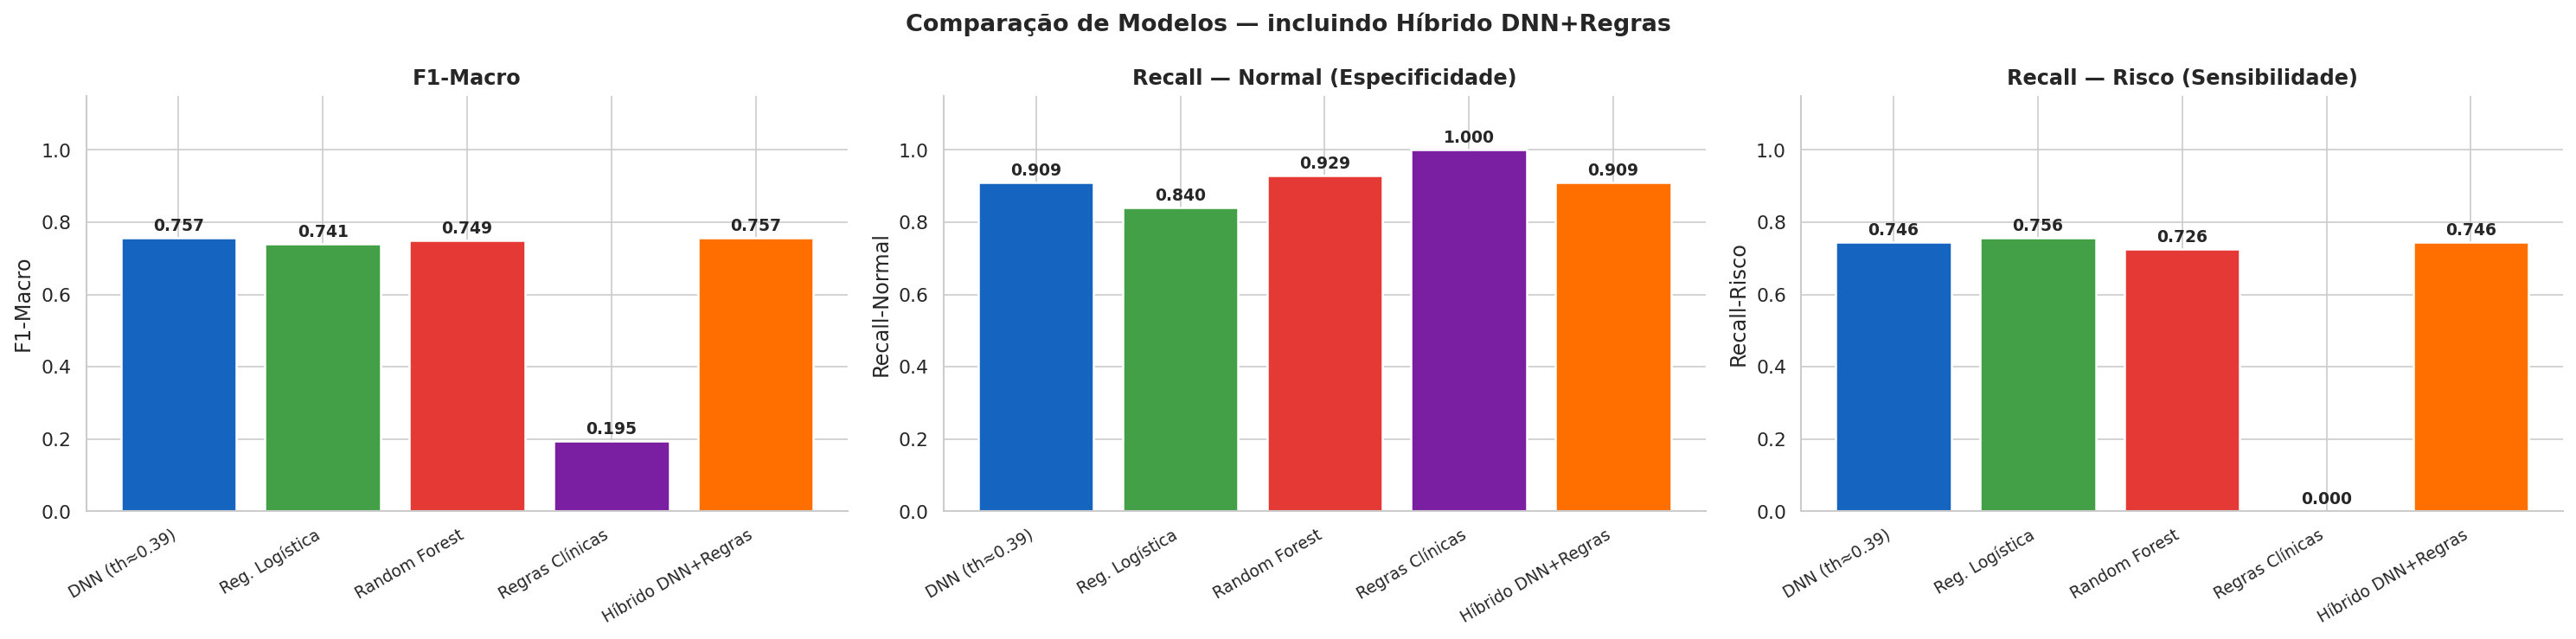

  Salvo: figures/08b_model_comparison_hybrid.png
            Modelo  F1-Macro  Recall-Normal  Recall-Risco  Acurácia
     DNN (th≈0.39)     0.757          0.909         0.746     0.785
    Reg. Logística     0.741          0.840         0.756     0.776
     Random Forest     0.749          0.929         0.726     0.775
   Regras Clínicas     0.195          1.000         0.000     0.243
Híbrido DNN+Regras     0.757          0.909         0.746     0.785


In [ ]:

print("\n" + "="*60)
print("   MODELO HÍBRIDO - DNN + VETO CLÍNICO")
print("="*60)
print("A DNN faz a predição primária.")
print("Regras clínicas têm poder de veto: se a DNN diz 'Normal' mas")
print("condições críticas co-ocorrem, o alerta é acionado de qualquer forma.\n")

def hybrid_predict(dnn_probs_anomalia, df_test_raw, threshold):
    # Predicoes DNN (baseadas em P(risco)) com veto clinico
    df_r         = df_test_raw.reset_index(drop=True)
    hybrid_preds = np.where(dnn_probs_anomalia >= threshold, 1, 0).copy()

    # Veto A: excesso de BPM E ritmo irregular simultâneos - sinal forte de arritmia ativa
    if 'bpm_excess' in df_r.columns and 'irregular_rhythm' in df_r.columns:
        veto_a = (df_r['bpm_excess'] > 30) & (df_r['irregular_rhythm'] == 1)
        hybrid_preds[veto_a.values & (hybrid_preds == 0)] = 1

    # Veto B: HRR > 85% em repouso - taquicardia sem esforço físico justificável
    if HAS_STEPS and 'is_active' in df_r.columns:
        bpm_rest = df_r['bpm'].quantile(0.10)
        hr_max   = (220 - df_r['age'].mean()) if HAS_DEMO else 190
        hrr_pct  = ((df_r['bpm'] - bpm_rest) / (hr_max - bpm_rest + 1e-8)).clip(0, 1)
        veto_b   = (hrr_pct > 0.85) & (df_r['is_active'] == 0)
        hybrid_preds[veto_b.values & (hybrid_preds == 0)] = 1

    return hybrid_preds


hybrid_preds = hybrid_predict(probs_anomalia, df_test_raw, THRESHOLD)
print_baseline_results("Híbrido DNN + Regras Clínicas", y_test, hybrid_preds)

# Score clínico do híbrido
score_hybrid = clinical_score(y_test, hybrid_preds)
print(f"\n  Score Clínico do Híbrido (penalty=10): {score_hybrid:.4f}")

# Gráfico de comparação final incluindo o Híbrido
metrics_list_hybrid = metrics_list + [
    model_metrics(y_test, hybrid_preds, "Híbrido DNN+Regras"),
]
df_metrics_hybrid  = pd.DataFrame(metrics_list_hybrid)
bar_colors_hybrid  = ["#1565C0", "#43A047", "#E53935", "#7B1FA2", "#FF6F00"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col, title in zip(axes, metric_cols, metric_titles):
    bars = ax.bar(df_metrics_hybrid["Modelo"], df_metrics_hybrid[col],
                  color=bar_colors_hybrid[:len(df_metrics_hybrid)], edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, df_metrics_hybrid[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(col)
    ax.set_xticklabels(df_metrics_hybrid["Modelo"], rotation=30, ha="right", fontsize=9)

plt.suptitle("Comparação de Modelos — incluindo Híbrido DNN+Regras", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("08b_model_comparison_hybrid")

print(df_metrics_hybrid.to_string(index=False))


In [ ]:

print("\n" + "="*60)
print("   ABLATION STUDY - CONTRIBUIÇÃO DE CADA GRUPO DE FEATURES")
print("="*60)
print("Treina Logistic Regression com subsets crescentes.")
print("Usa os mesmos pesos de classe calculados do dataset (class_weight_dict).")
print(f"  class_weight_dict = {class_weight_dict}\n")

def ablation_eval(X_tr, X_te, y_tr, y_te, label):
    # Usa class_weight_dict para ser consistente com todos os outros modelos
    clf = LogisticRegression(class_weight=class_weight_dict, random_state=42, max_iter=1000)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    recall_normal   = recall_score(y_te, preds, pos_label=0, zero_division=0)
    recall_anomalia = recall_score(y_te, preds, pos_label=1, zero_division=0)
    f1_macro        = f1_score(y_te, preds, average='macro', zero_division=0)
    acc             = (preds == y_te).mean()
    print(f"  {label:<50} | Acc={acc:.3f} | F1-macro={f1_macro:.3f}"
          f" | Recall-Normal={recall_normal:.3f} | Recall-Risco={recall_anomalia:.3f}")

print(f"  {'Conjunto de Features':<50} | {'Acc':^5}   {'F1-macro':^8}   "
      f"{'Recall-Normal':^13}   {'Recall-Risco':^12}")
print("  " + "-"*110)

idx = {f: i for i, f in enumerate(temporal_features)}

# BPM (frequência cardíaca) - sempre disponível
bpm_base = ['bpm', 'bpm_rolling_mean', 'bpm_rolling_std', 'bpm_diff']
bpm_idx  = [idx[f] for f in bpm_base]
ablation_eval(
    X_train_temp_scaled[:, bpm_idx], X_test_temp_scaled[:, bpm_idx],
    y_train, y_test, "BPM (frequência cardíaca)"
)

# Passos - apenas se disponível no banco
if HAS_STEPS:
    steps_feats = bpm_base + ['steps_rolling_mean', 'is_active', 'bpm_excess']
    steps_idx   = [idx[f] for f in steps_feats]
    ablation_eval(
        X_train_temp_scaled[:, steps_idx], X_test_temp_scaled[:, steps_idx],
        y_train, y_test, "+ Passos / acelerômetro (steps, is_active, bpm_excess)"
    )

# RR / HRV - apenas se disponível no banco
if HAS_RR:
    rr_base   = (steps_feats if HAS_STEPS else bpm_base)
    rr_feats  = rr_base + ['rr_rolling_mean', 'rr_rolling_std', 'rr_rmssd', 'rr_cv', 'irregular_rhythm']
    rr_idx    = [idx[f] for f in rr_feats]
    ablation_eval(
        X_train_temp_scaled[:, rr_idx], X_test_temp_scaled[:, rr_idx],
        y_train, y_test, "+ Ritmo cardíaco / HRV (rr_*, irregular_rhythm)"
    )

# Todas as features temporais
ablation_eval(
    X_train_temp_scaled, X_test_temp_scaled,
    y_train, y_test, "Todas as features temporais"
)

# Demográfico - apenas se disponível no banco
if demographic_features:
    ablation_eval(
        np.hstack([X_train_temp_scaled, X_train_demo_scaled]),
        np.hstack([X_test_temp_scaled,  X_test_demo_scaled]),
        y_train, y_test, "+ Demográfico (age, sex)"
    )

# Clínico - apenas se disponível no banco
if clinical_features:
    ablation_eval(
        X_train_flat, X_test_flat,
        y_train, y_test, "+ Histórico Clínico  ← modelo completo"
    )

print("\nNota: o ablation usa Regressão Logística (modelo linear) — valores")
print("  diferentes dos outros modelos são ESPERADOS por design:")
print("  • DNN:  não-linear, loss focal, threshold otimizado por F2")
print("  • RF:   baseado em árvores, threshold THRESHOLD")
print("  • Ablation: LR linear, threshold padrão 0.5, mesmos pesos balanced")
print("\nInterpretação:")
print("  - Recall-Normal  → % de saudáveis corretamente identificados (especificidade)")
print("  - Recall-Risco   → % de anomalias detectadas (sensibilidade clínica — mais crítico)")
print("  - F1-macro       → equilíbrio geral entre as duas classes")



   ABLATION STUDY - CONTRIBUIÇÃO DE CADA GRUPO DE FEATURES
Treina Logistic Regression com subsets crescentes.
Usa os mesmos pesos de classe calculados do dataset (class_weight_dict).
  class_weight_dict = {0: 2.060419472977488, 1: 0.6602133300239882}

  Conjunto de Features                               |  Acc    F1-macro   Recall-Normal   Recall-Risco
  --------------------------------------------------------------------------------------------------------------
  BPM (frequência cardíaca)                          | Acc=0.772 | F1-macro=0.738 | Recall-Normal=0.856 | Recall-Risco=0.745
  Todas as features temporais                        | Acc=0.772 | F1-macro=0.738 | Recall-Normal=0.856 | Recall-Risco=0.745

Nota: o ablation usa Regressão Logística (modelo linear) — valores
  diferentes dos outros modelos são ESPERADOS por design:
  • DNN:  não-linear, loss focal, threshold otimizado por F2
  • RF:   baseado em árvores, threshold THRESHOLD
  • Ablation: LR linear, threshold padrão 0.

In [ ]:

model.save("models/cardiac_risk_model.keras")

joblib.dump(scaler_temporal, "models/scaler_temporal.pkl")
if demographic_features:
    joblib.dump(scaler_demo, "models/scaler_demo.pkl")

feature_config = {
    'temporal_features':    temporal_features,
    'demographic_features': demographic_features,
    'clinical_features':    clinical_features,
    'continuous_features':  continuous_features,
    'binary_features':      binary_features,
    'temporal_continuous_idx': temporal_continuous_idx,
    'demo_continuous_idx':  [i for i, f in enumerate(demographic_features) if f in continuous_features]
                            if demographic_features else [],
}
joblib.dump(feature_config, "models/feature_config.pkl")

print("Modelo e artefatos salvos:")
print("  - models/cardiac_risk_model.keras")
print("  - models/scaler_temporal.pkl")
if demographic_features:
    print("  - models/scaler_demo.pkl")
print("  - models/feature_config.pkl")


Modelo e artefatos salvos:
  - models/cardiac_risk_model.keras
  - models/scaler_temporal.pkl
  - models/feature_config.pkl
